In [1]:
import wfdb
import neurokit2 as nk

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
record = wfdb.rdrecord(
    "ptb-diagnostic-ecg-database-1.0.0/patient001/s0010_re"
)

In [3]:
signal = record.p_signal[:,1]

In [4]:
cleaned = nk.ecg_clean(
    signal,
    sampling_rate=record.fs,
    method="neurokit"
)

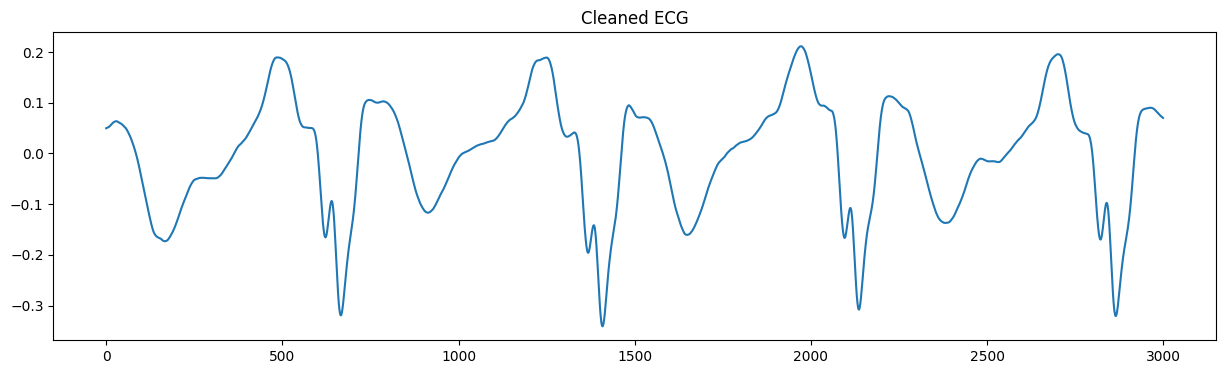

In [5]:
plt.figure(figsize=(15,4))

plt.plot(cleaned[:3000])

plt.title("Cleaned ECG")

plt.show()

[ 636 1379 2107 2836 3581 4321 5050 5794 6535 7258]


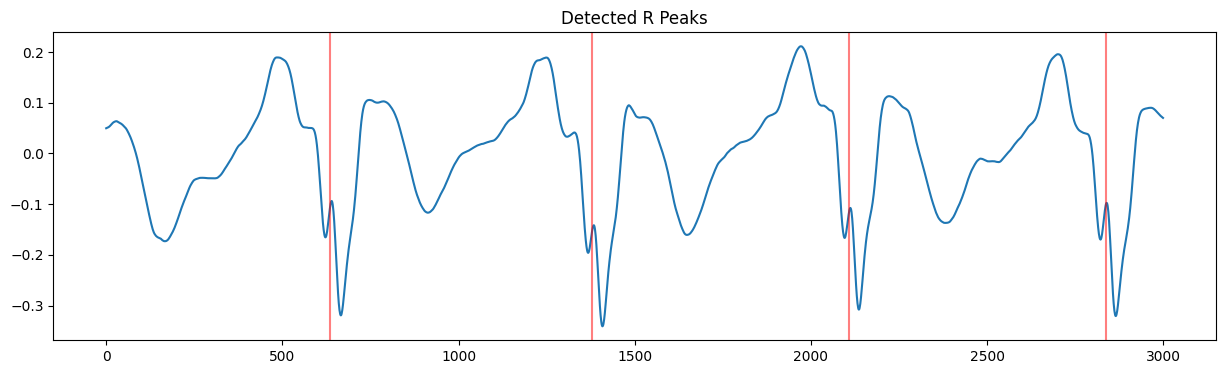

In [8]:
# R-peak detection
signals, info = nk.ecg_process(
    cleaned,
    sampling_rate=record.fs
)
r_peaks = info["ECG_R_Peaks"]

print(r_peaks[:10])

plt.figure(figsize=(15,4))

plt.plot(cleaned[:3000])

for peak in r_peaks:

    if peak < 3000:

        plt.axvline(
            x=peak,
            color="red",
            alpha=0.5
        )

plt.title("Detected R Peaks")

plt.show()

## ECG DELINEATION

In [9]:
_, waves = nk.ecg_delineate(
    cleaned,
    r_peaks,
    sampling_rate=record.fs,
    method="dwt"
)

In [10]:
print(waves.keys())

dict_keys(['ECG_P_Peaks', 'ECG_P_Onsets', 'ECG_P_Offsets', 'ECG_Q_Peaks', 'ECG_R_Onsets', 'ECG_R_Offsets', 'ECG_S_Peaks', 'ECG_T_Peaks', 'ECG_T_Onsets', 'ECG_T_Offsets'])


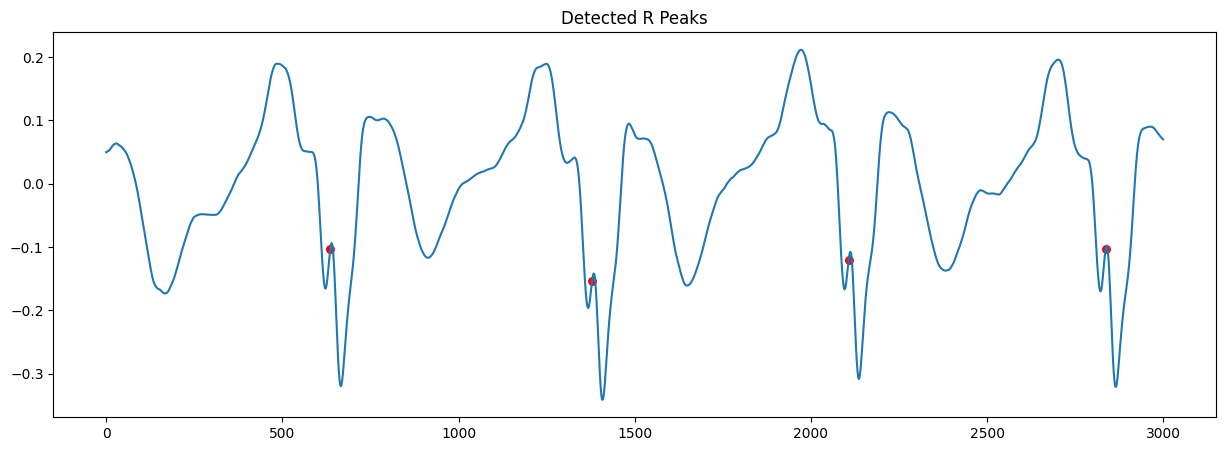

In [15]:
plt.figure(figsize=(15,5))

plt.plot(cleaned[:3000])

# R peaks
for x in r_peaks:

    if x < 3000:

        plt.scatter(
            x,
            cleaned[x],
            color="red",
            s=30
        )

plt.title("Detected R Peaks")

plt.show()

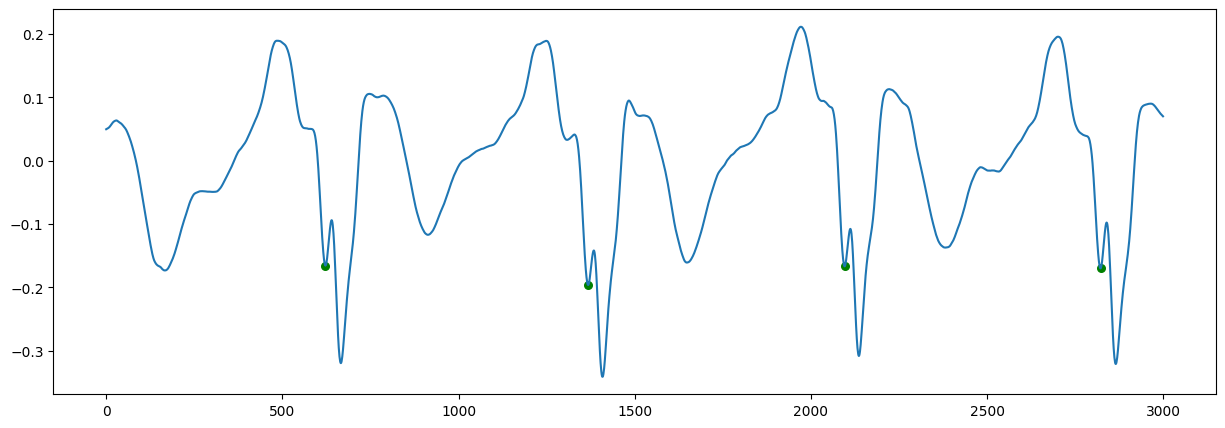

In [ ]:
# Q peak
plt.figure(figsize=(15,5))

plt.plot(cleaned[:3000])
for x in waves["ECG_Q_Peaks"]:

    if not np.isnan(x):

        x = int(x)

        if x < 3000:

            plt.scatter(

                x,

                cleaned[x],

                color="green",

                s=30,

                label="Q Peak"
            )

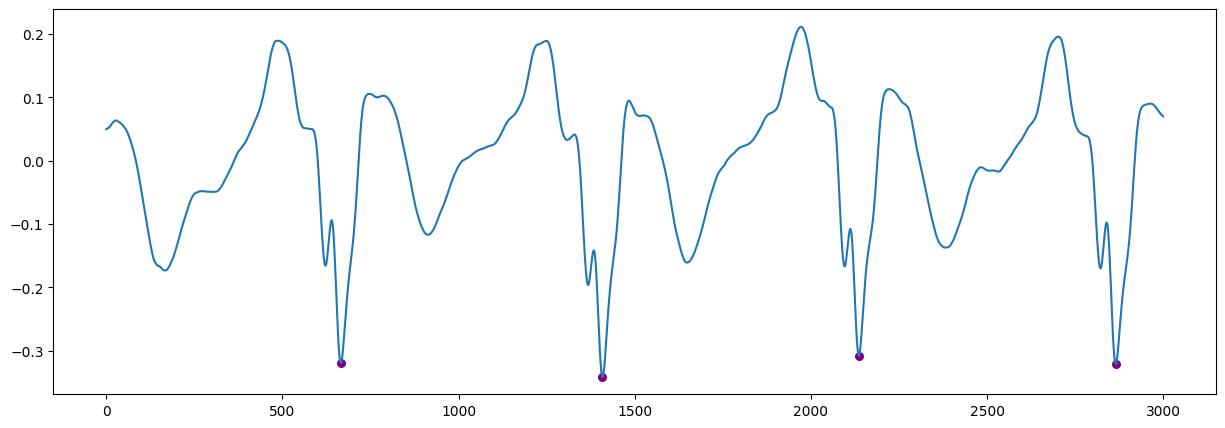

In [18]:
# S peak
plt.figure(figsize=(15,5))

plt.plot(cleaned[:3000])
for x in waves["ECG_S_Peaks"]:

    if not np.isnan(x):

        x = int(x)

        if x < 3000:

            plt.scatter(

                x,

                cleaned[x],

                color="purple",

                s=30,

                label="S Peak"
            )

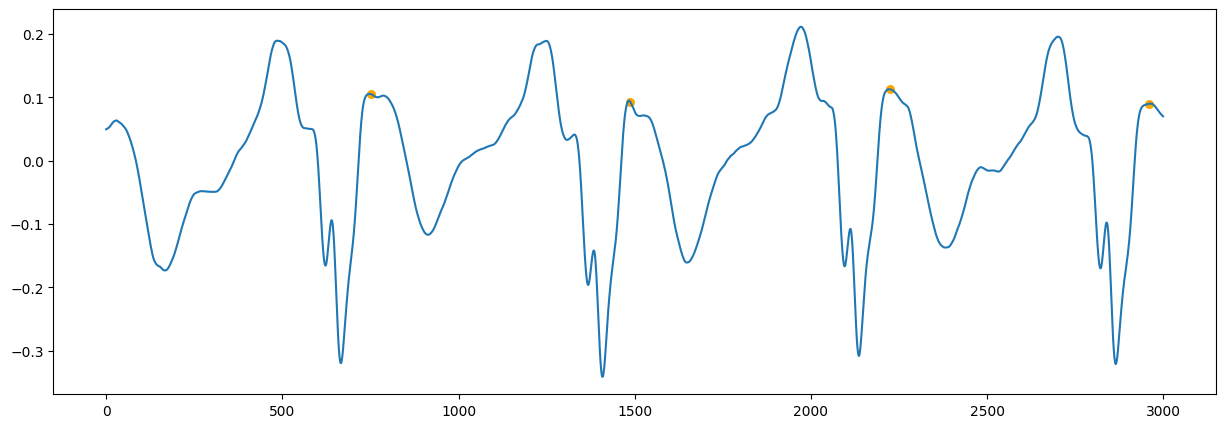

In [20]:
# T peak
plt.figure(figsize=(15,5))

plt.plot(cleaned[:3000])
for x in waves["ECG_T_Peaks"]:

    if not np.isnan(x):

        x = int(x)

        if x < 3000:

            plt.scatter(

                x,

                cleaned[x],

                color="orange",

                s=30,

                label="T Peak"
            )

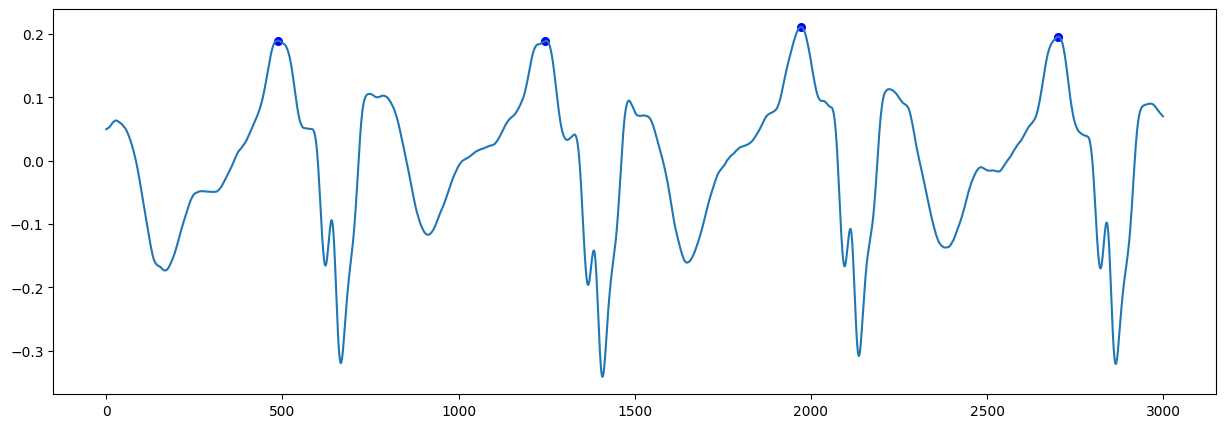

In [21]:
# P peak
plt.figure(figsize=(15,5))

plt.plot(cleaned[:3000])

for x in waves["ECG_P_Peaks"]:

    if not np.isnan(x):

        x = int(x)

        if x < 3000:

            plt.scatter(

                x,

                cleaned[x],

                color="blue",

                s=30,

                label="P Peak"
            )

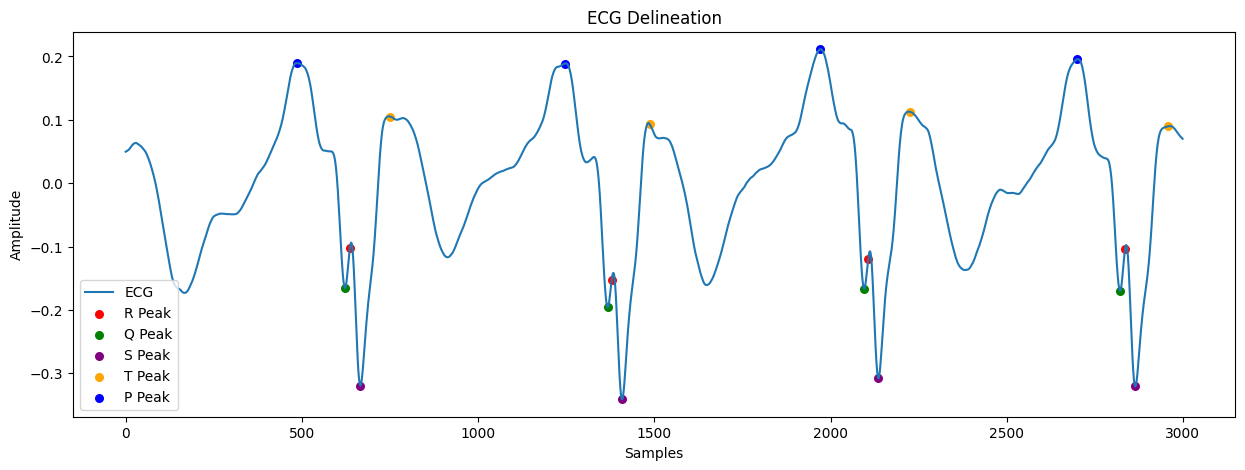

In [24]:
plt.figure(figsize=(15,5))

plt.plot(
    cleaned[:3000],
    label="ECG"
)

# =====================
# R PEAKS
# =====================

for x in r_peaks:

    if x < 3000:

        plt.scatter(

            x,

            cleaned[x],

            color="red",

            s=30,

            label="R Peak"
        )

# =====================
# Q PEAKS
# =====================

for x in waves["ECG_Q_Peaks"]:

    if not np.isnan(x):

        x = int(x)

        if x < 3000:

            plt.scatter(

                x,

                cleaned[x],

                color="green",

                s=30,

                label="Q Peak"
            )

# =====================
# S PEAKS
# =====================

for x in waves["ECG_S_Peaks"]:

    if not np.isnan(x):

        x = int(x)

        if x < 3000:

            plt.scatter(

                x,

                cleaned[x],

                color="purple",

                s=30,

                label="S Peak"
            )

# =====================
# T PEAKS
# =====================

for x in waves["ECG_T_Peaks"]:

    if not np.isnan(x):

        x = int(x)

        if x < 3000:

            plt.scatter(

                x,

                cleaned[x],

                color="orange",

                s=30,

                label="T Peak"
            )

# =====================
# P PEAKS
# =====================

for x in waves["ECG_P_Peaks"]:

    if not np.isnan(x):

        x = int(x)

        if x < 3000:

            plt.scatter(

                x,

                cleaned[x],

                color="blue",

                s=30,

                label="P Peak"
            )

# =====================
# CLEAN LEGEND
# =====================

handles, labels = plt.gca().get_legend_handles_labels()

by_label = dict(
    zip(labels, handles)
)

plt.legend(
    by_label.values(),
    by_label.keys()
)

plt.title(
    "ECG Delineation"
)

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.show()